**Title cell**: purpose, author, date, event and item IDs used, link to the Overview, and one-line summary of findings.

**Setup cell notes**: libraries and versions, plus a line explaining that everything runs in free Colab with no local installs.


**Every code cell gets a markdown cell above** it saying what it does, why, and what the reader should expect to see. Explain the why (for example, why windowed reads instead of full download).

**Named constants at the top**: item IDs, tile size, window offsets, so teammates can swap scenes without hunting through code.


**Print metadata instead of assuming it**: show dtype, shape, CRS output in the notebook so the reader can verify.


**Consistent figure conventions**: titles that include the item ID and window, no unlabeled axes, same tile size across figures.


**Observation cells written like evidence**: each claim points to a specific figure. Bad: "clouds look white." Good: "Tile 4 shows thin cirrus where road edges remain visible through the haze, which will defeat a pure brightness threshold because pixel values sit below the thick-cloud range."


**Limitations section**: what you did not verify (for example, metadata cloud % vs your visual estimate, single event only).

**Reproducibility check**: Restart runtime, Run all, confirm no errors before you share. Nothing beats a notebook that runs clean on the first try for a teammate.

**Prior work section**: dark-channel prior in your own words (idea, assumption, where it fails on this data), the citation, and the metrics list (IoU, precision, recall, F1) with one sentence on why label ambiguity limits IoU on thin cloud.

**0-10:** Pick the event and 3 to 4 candidate items in the STAC browser. Log them in a table (event, item ID, metadata cloud %, one-line visual note). Write the table cell in the notebook as you go.

In [ ]:
import pystac
import pandas as pd
import matplotlib.pyplot as plt
import rasterio
import numpy as np
from rasterio.windows import Window

**New Zealand Flooding 2023 Data Exploration**

In [ ]:
# Scene1 Exploration - 7% cloud
nz_item_url = "https://maxar-opendata.s3.amazonaws.com/events/New-Zealand-Flooding23/ard/60/213311212310/2022-12-11/10300100DE4D9300.json"
item = pystac.Item.from_file(nz_item_url)
print("ID: ", item.id)
print("Date time: ", item.datetime)
print(item.assets)

# Visual COG URL
url_from_code = item.assets["visual"].get_absolute_href()
print(url_from_code)
print(url_from_code == "https://maxar-opendata.s3.amazonaws.com/events/New-Zealand-Flooding23/ard/60/213311212310/2022-12-11/10300100DE4D9300-visual.tif")

ID:  60/213311212310/10300100DE4D9300
Date time:  2022-12-11 22:13:04+00:00
{'data-mask': <Asset href=./10300100DE4D9300-data-mask.gpkg>, 'ms_analytic': <Asset href=./10300100DE4D9300-ms.tif>, 'pan_analytic': <Asset href=./10300100DE4D9300-pan.tif>, 'visual': <Asset href=./10300100DE4D9300-visual.tif>}
https://maxar-opendata.s3.amazonaws.com/events/New-Zealand-Flooding23/ard/60/213311212310/2022-12-11/10300100DE4D9300-visual.tif
True


In [ ]:
# Scene2 Exploration - 15% cloud
nz_item2_url = "https://maxar-opendata.s3.amazonaws.com/events/New-Zealand-Flooding23/ard/60/213311212303/2022-12-11/10300100DE4D9300.json"
item2 = pystac.Item.from_file(nz_item2_url)
print("ID: ", item2.id)
print("Date time: ", item2.datetime)
print(item2.assets)

# Visual COG URl
url2_from_code = item2.assets["visual"].get_absolute_href()
print(url2_from_code)
print(url2_from_code == "https://maxar-opendata.s3.amazonaws.com/events/New-Zealand-Flooding23/ard/60/213311212303/2022-12-11/10300100DE4D9300-visual.tif")


ID:  60/213311212303/10300100DE4D9300
Date time:  2022-12-11 22:13:03+00:00
{'data-mask': <Asset href=./10300100DE4D9300-data-mask.gpkg>, 'ms_analytic': <Asset href=./10300100DE4D9300-ms.tif>, 'pan_analytic': <Asset href=./10300100DE4D9300-pan.tif>, 'visual': <Asset href=./10300100DE4D9300-visual.tif>}
https://maxar-opendata.s3.amazonaws.com/events/New-Zealand-Flooding23/ard/60/213311212303/2022-12-11/10300100DE4D9300-visual.tif
True


In [ ]:
# Scene3 Exploration - 4% Cloud

nz_item3_url = "https://maxar-opendata.s3.amazonaws.com/events/New-Zealand-Flooding23/ard/60/213311212312/2022-12-11/10300100DE4D9300.json"
item3 = pystac.Item.from_file(nz_item3_url)
print("ID: ", item3.id)
print("Date time: ", item3.datetime)
print(item3.assets)

# Visaual COG URl
url3_from_code = item3.assets["visual"].get_absolute_href()
print(url3_from_code)
print(url2_from_code == "https://maxar-opendata.s3.amazonaws.com/events/New-Zealand-Flooding23/ard/60/213311212312/2022-12-11/10300100DE4D9300-visual.tif")

ID:  60/213311212312/10300100DE4D9300
Date time:  2022-12-11 22:13:03+00:00
{'data-mask': <Asset href=./10300100DE4D9300-data-mask.gpkg>, 'ms_analytic': <Asset href=./10300100DE4D9300-ms.tif>, 'pan_analytic': <Asset href=./10300100DE4D9300-pan.tif>, 'visual': <Asset href=./10300100DE4D9300-visual.tif>}
https://maxar-opendata.s3.amazonaws.com/events/New-Zealand-Flooding23/ard/60/213311212312/2022-12-11/10300100DE4D9300-visual.tif
False


**Belize Wilde Fire Data Exploration**

In [ ]:
# Scene 1 Exploration - 36% Cloud
b_item1_url = "https://maxar-opendata.s3.amazonaws.com/events/Belize-Wildfires-June24/ard/16/033131012120/2024-05-27/10300100FDC7C400.json"
b_item1 = pystac.Item.from_file(b_item1_url)
print("ID: ", b_item1.id)
print("Date time: ", b_item1.datetime)
print(b_item1.assets)

#Visual COG URL
b_url1_from_code = b_item1.assets["visual"].get_absolute_href()
print(b_url1_from_code)
print(b_url1_from_code == "https://maxar-opendata.s3.amazonaws.com/events/Belize-Wildfires-June24/ard/16/033131012120/2024-05-27/10300100FDC7C400-visual.tif")


ID:  16/033131012120/10300100FDC7C400
Date time:  2024-05-27 16:27:17+00:00
{'data-mask': <Asset href=./10300100FDC7C400-data-mask.gpkg>, 'ms_analytic': <Asset href=./10300100FDC7C400-ms.tif>, 'pan_analytic': <Asset href=./10300100FDC7C400-pan.tif>, 'visual': <Asset href=./10300100FDC7C400-visual.tif>}
https://maxar-opendata.s3.amazonaws.com/events/Belize-Wildfires-June24/ard/16/033131012120/2024-05-27/10300100FDC7C400-visual.tif
True


In [ ]:
# Scene 2 Exploration - 43% Cloud
b_item2_url = "https://maxar-opendata.s3.amazonaws.com/events/Belize-Wildfires-June24/ard/16/033131012121/2024-05-27/10300100FDC7C400.json"
b_item2 = pystac.Item.from_file(b_item2_url)
print("ID: ", b_item2.id)
print("Date time: ", b_item2.datetime)
print(b_item2.assets)

#Visual COG URL
b_url2_from_code = b_item2.assets["visual"].get_absolute_href()
print(b_url2_from_code)
print(b_url2_from_code == "https://maxar-opendata.s3.amazonaws.com/events/Belize-Wildfires-June24/ard/16/033131012121/2024-05-27/10300100FDC7C400-visual.tif")


ID:  16/033131012121/10300100FDC7C400
Date time:  2024-05-27 16:27:17+00:00
{'data-mask': <Asset href=./10300100FDC7C400-data-mask.gpkg>, 'ms_analytic': <Asset href=./10300100FDC7C400-ms.tif>, 'pan_analytic': <Asset href=./10300100FDC7C400-pan.tif>, 'visual': <Asset href=./10300100FDC7C400-visual.tif>}
https://maxar-opendata.s3.amazonaws.com/events/Belize-Wildfires-June24/ard/16/033131012121/2024-05-27/10300100FDC7C400-visual.tif
True


In [ ]:
# Scene 3 Exploration - 17% Cloud
b_item3_url = "https://maxar-opendata.s3.amazonaws.com/events/Belize-Wildfires-June24/ard/16/033131012122/2024-05-27/10300100FDC7C400.json"
b_item3 = pystac.Item.from_file(b_item3_url)
print("ID: ", b_item3.id)
print("Date time: ", b_item3.datetime)
print(b_item3.assets)

#Visual COG URL
b_url3_from_code = b_item3.assets["visual"].get_absolute_href()
print(b_url3_from_code)
print(b_url3_from_code == "https://maxar-opendata.s3.amazonaws.com/events/Belize-Wildfires-June24/ard/16/033131012121/2024-05-27/10300100FDC7C400-visual.tif")


ID:  16/033131012122/10300100FDC7C400
Date time:  2024-05-27 16:27:17+00:00
{'data-mask': <Asset href=./10300100FDC7C400-data-mask.gpkg>, 'ms_analytic': <Asset href=./10300100FDC7C400-ms.tif>, 'pan_analytic': <Asset href=./10300100FDC7C400-pan.tif>, 'visual': <Asset href=./10300100FDC7C400-visual.tif>}
https://maxar-opendata.s3.amazonaws.com/events/Belize-Wildfires-June24/ard/16/033131012122/2024-05-27/10300100FDC7C400-visual.tif
False


**Bay of Bengal Cyclone Mocha 2023**

Cyclone Mocha, a category five cyclone with 130 mph winds and torrential rain, hit parts of Myanmar and Bangladesh, forcing mass evacuations ahead of the storm. The cyclone, one of the most powerful to hit the region in the last decade, made landfall on Sunday, May 14, 2023, near Sittwe in Myanmar's Rakhine state. Rain and a storm surge caused widespread flooding in low-lying areas. The United National Office Coordination of Humanitarian Affairs stated that there had been extensive damage among already vulnerable communities and that communications with the affected areas have been difficult.



In [ ]:
# Scene 1 Exploration - 19% Cloud Detection
bengal_item1_url = "https://maxar-opendata.s3.amazonaws.com/events/BayofBengal-Cyclone-Mocha-May-23/ard/46/033111333000/2023-05-22/10300100E6747500.json"
bengal_item1 = pystac.Item.from_file(bengal_item1_url)
print("ID: ", bengal_item1.id)
print("Date Time: ", bengal_item1.datetime)
print(bengal_item1.assets)

#Visual COG URL
bengal_url1_from_code = bengal_item1.assets["visual"].get_absolute_href()
print(bengal_url1_from_code)
print(bengal_url1_from_code == "https://maxar-opendata.s3.amazonaws.com/events/BayofBengal-Cyclone-Mocha-May-23/ard/46/033111333000/2023-05-22/10300100E6747500-visual.tif")

ID:  46/033111333000/10300100E6747500
Date Time:  2023-05-22 04:35:08+00:00
{'data-mask': <Asset href=./10300100E6747500-data-mask.gpkg>, 'ms_analytic': <Asset href=./10300100E6747500-ms.tif>, 'pan_analytic': <Asset href=./10300100E6747500-pan.tif>, 'visual': <Asset href=./10300100E6747500-visual.tif>}
https://maxar-opendata.s3.amazonaws.com/events/BayofBengal-Cyclone-Mocha-May-23/ard/46/033111333000/2023-05-22/10300100E6747500-visual.tif
True


In [ ]:
# Scene 2 Exploration - 3% Cloud Detection
bengal_item2_url = "https://maxar-opendata.s3.amazonaws.com/events/BayofBengal-Cyclone-Mocha-May-23/ard/46/033111333003/2023-05-22/10300100E6747500.json"
bengal_item2 = pystac.Item.from_file(bengal_item2_url)
print("ID: ", bengal_item2.id)
print("Date Time: ", bengal_item2.datetime)
print(bengal_item2.assets)

#Visual COG URL
bengal_url2_from_code = bengal_item2.assets["visual"].get_absolute_href()
print(bengal_url2_from_code)
print(bengal_url2_from_code == "https://maxar-opendata.s3.amazonaws.com/events/BayofBengal-Cyclone-Mocha-May-23/ard/46/033111333003/2023-05-22/10300100E6747500-visual.tif")

ID:  46/033111333003/10300100E6747500
Date Time:  2023-05-22 04:35:09+00:00
{'data-mask': <Asset href=./10300100E6747500-data-mask.gpkg>, 'ms_analytic': <Asset href=./10300100E6747500-ms.tif>, 'pan_analytic': <Asset href=./10300100E6747500-pan.tif>, 'visual': <Asset href=./10300100E6747500-visual.tif>}
https://maxar-opendata.s3.amazonaws.com/events/BayofBengal-Cyclone-Mocha-May-23/ard/46/033111333003/2023-05-22/10300100E6747500-visual.tif
True


**Dictionary**

In [ ]:
scenes = {
    "NZ_1": item,
    "NZ_2": item2,
    "NZ_3": item3,
    "Belize_1": b_item1,
    "Belize_2": b_item2,
    "Belize_3": b_item3,
    "Bengal_1": bengal_item1,
    "Bengal_2": bengal_item2,
    #"Bengal_3": bengal_item3 #(Coming up)
    }

# labels (event name, metadata cloud % read from the STAC browser)
manual = {
    "NZ_1": ("New-Zealand-Flooding-2023", 7),
    "NZ_2": ("New-Zealand-Flooding-2023", 15),
    "NZ_3": ("New-Zealand-Flooding-2023", 4),
    "Belize_1": ("Belize-Wildfires-June-2024", 36),
    "Belize_2": ("Belize-Wildfires-June-2024", 43),
    "Belize_3": ("Belize-Wildefired-June-2024", 17),
    "Bengal_1": ("BayofBengal-Cyclone-Mocha-May-23", 19),
    "Bengal_2": ("BayofBengal-Cyclone-Mocha-May-23", 3),
    # "Bengal_3": ("BayofBengal-Cyclone-Mocha-May-23", __)
}

# Build the small dictionary per scene
rows = []

# Look up the values I entered by hand for this label in `manual`.
# These came from the STAC browser page, not from the item object.

for label, it in scenes.items():
  event, cloud = manual[label]
  rows.append({
        "label": label,
        "event": event,
        "date": it.datetime.date(),
        "item_id": it.id,
        "cloud_pct_metadata": cloud,
        "cog_url": it.assets["visual"].get_absolute_href(),
    })

df = pd.DataFrame(rows)
df

,label,event,date,item_id,cloud_pct_metadata,cog_url
0,NZ_1,New-Zealand-Flooding-2023,2022-12-11,60/213311212310/10300100DE4D9300,7,https://maxar-opendata.s3.amazonaws.com/events...
1,NZ_2,New-Zealand-Flooding-2023,2022-12-11,60/213311212303/10300100DE4D9300,15,https://maxar-opendata.s3.amazonaws.com/events...
2,NZ_3,New-Zealand-Flooding-2023,2022-12-11,60/213311212312/10300100DE4D9300,4,https://maxar-opendata.s3.amazonaws.com/events...
3,Belize_1,Belize-Wildfires-June-2024,2024-05-27,16/033131012120/10300100FDC7C400,36,https://maxar-opendata.s3.amazonaws.com/events...
4,Belize_2,Belize-Wildfires-June-2024,2024-05-27,16/033131012121/10300100FDC7C400,43,https://maxar-opendata.s3.amazonaws.com/events...
5,Belize_3,Belize-Wildefired-June-2024,2024-05-27,16/033131012122/10300100FDC7C400,17,https://maxar-opendata.s3.amazonaws.com/events...
6,Bengal_1,BayofBengal-Cyclone-Mocha-May-23,2023-05-22,46/033111333000/10300100E6747500,19,https://maxar-opendata.s3.amazonaws.com/events...
7,Bengal_2,BayofBengal-Cyclone-Mocha-May-23,2023-05-22,46/033111333003/10300100E6747500,3,https://maxar-opendata.s3.amazonaws.com/events...


Exploring scenes with rasterio and leafmap

Bands:  3
Width:  17408
Height:  17408
EPSG:32760
Resolution: (0.30517578125, 0.30517578125)
Data Type:  ('uint8', 'uint8', 'uint8')
None
[2, 4, 8, 16, 32, 64]
uint8
(3, 1088, 1088)
Window shape: (3, 1024, 1024)


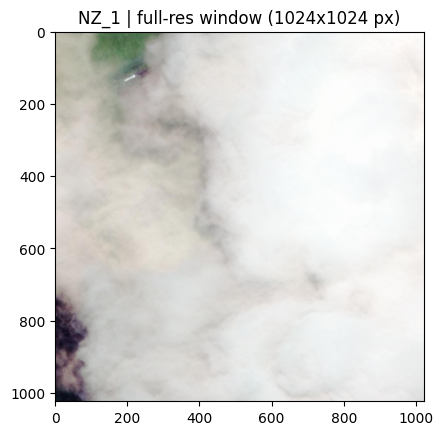

In [ ]:
# NZ_1 7%
# Coordinates below were read off the downsampled plot (Step 3) and
# multiplied by 16, since that plot was 1/16 scale.
col_off = 3200   # x start, in full-resolution pixels
row_off = 14400  # y start, in full-resolution pixels
win_size = 1024  # window is win_size x win_size pixels


with rasterio.open(url_from_code) as src:
  print("Bands: ", src.count)
  print("Width: " , src.width)
  print("Height: ", src.height)
  print(src.crs)
  print("Resolution:", src.res)
  print("Data Type: ", src.dtypes)
  print(src.nodata)
  print(src.overviews(1))

  target = src.width //16
  r = src.read(out_shape = (3, target, target))
  print(r.dtype)
  print(r.shape)



  # transpose to (height, width, band)
  window = Window(col_off, row_off, win_size, win_size)
  w = src.read(window=window)
  print("Window shape:", w.shape)
  img_full = np.transpose(w, (1, 2, 0))


  #Print statements
  plt.imshow(img_full)
  plt.title(f"NZ_1 | full-res window ({win_size}x{win_size} px)")
  plt.show()

## Step 4: Full-resolution window

The overview image in Step 3 was downsampled 16x, so fine detail
(thin cloud edges, shadow boundaries) is blurred away. Here we read
one small rectangle of the original image at full resolution instead
of the whole scene, which keeps the file size manageable.

- A `Window` is defined by an (x, y) starting pixel and a width/height,
  all in full-resolution pixel units.
- `col_off`/`row_off` were estimated by reading pixel coordinates off
  the Step 3 plot and multiplying by 16 (the downsample factor), since
  that plot was scaled down 16x from the original.
- `src.read(window=...)` reads only that rectangle from the file
  rather than the full 17408x17408 array, so it stays fast and small.
- The same transpose as Step 3 is needed before `imshow`, since
  rasterio and matplotlib order axes differently.

**What to look for:** compare this crop to the same area in Step 3.
Cloud edges should look sharper, and you should be able to tell
whether the cloud is opaque (fully white, ground invisible) or thin
(ground features faintly visible through it). Note what you see in
one sentence under the figure.

Bands:  3
Width:  17408
Height:  17408
EPSG:32616
Resolution: (0.30517578125, 0.30517578125)
Data Type:  ('uint8', 'uint8', 'uint8')
None
[2, 4, 8, 16, 32, 64]
uint8
(3, 1088, 1088)
Window shape: (3, 1024, 1024)


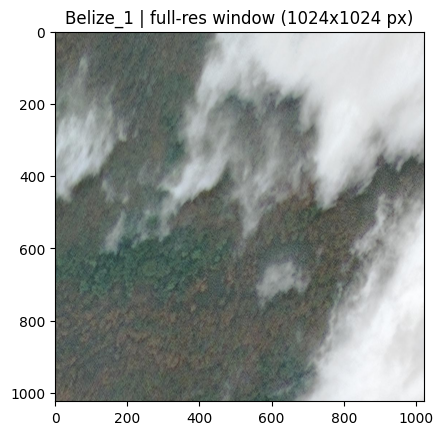

In [ ]:
# Coordinates below were read off the downsampled plot (Step 3) and
# multiplied by 16, since that plot was 1/16 scale.
col_off = 600*16   # x start, in full-resolution pixels
row_off = 750*16  # y start, in full-resolution pixels
win_size = 1024  # window is win_size x win_size pixels


with rasterio.open(b_url2_from_code) as src:
  print("Bands: ", src.count)
  print("Width: " , src.width)
  print("Height: ", src.height)
  print(src.crs)
  print("Resolution:", src.res)
  print("Data Type: ", src.dtypes)
  print(src.nodata)
  print(src.overviews(1))

  target = src.width //16
  r = src.read(out_shape = (3, target, target))
  print(r.dtype)
  print(r.shape)



# Full-resolution crop at the coordinates picked from the overview above
  window = Window(col_off, row_off, win_size, win_size)
  w = src.read(window=window)
  print("Window shape:", w.shape)

  img_full = np.transpose(w, (1, 2, 0))
  plt.imshow(img_full)
  plt.title(f"Belize_1 | full-res window ({win_size}x{win_size} px)")
  plt.show()

**New Zealand Observation**: This crop is strong. There is a dense opaque cloud (upper right), forest with visible cloud shadow patches (lower left), and a clean diagonal boundary between them, plus one soft wisp of thin cloud near the middle. That range, thick, shadow, and a clear/cloud edge, is a good variety to keep.